In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150,
})

COLORS = {
    ('random', 'nearestx'): '#1f77b4',
    ('random', 'str'):      '#aec7e8',
    ('europa', 'nearestx'): '#d62728',
    ('europa', 'str'):      '#f5a09b',
}
MARKERS = {
    ('random', 'nearestx'): 'o',
    ('random', 'str'):      's',
    ('europa', 'nearestx'): 'o',
    ('europa', 'str'):      's',
}
LABELS = {
    ('random', 'nearestx'): 'Random — Nearest-X',
    ('random', 'str'):      'Random — STR',
    ('europa', 'nearestx'): 'Europa — Nearest-X',
    ('europa', 'str'):      'Europa — STR',
}
os.makedirs('plots', exist_ok=True)

## 5.1 — Tiempo de construcción vs N

In [7]:
build = pd.read_csv('build_results.csv')
build['N'] = build['N'].astype(int)
build.head()

,dataset,method,N,time_ms
0,random,nearestx,32768,2.394
1,random,str,32768,3.859
2,random,nearestx,65536,4.930
3,random,str,65536,8.016
4,random,nearestx,131072,10.218


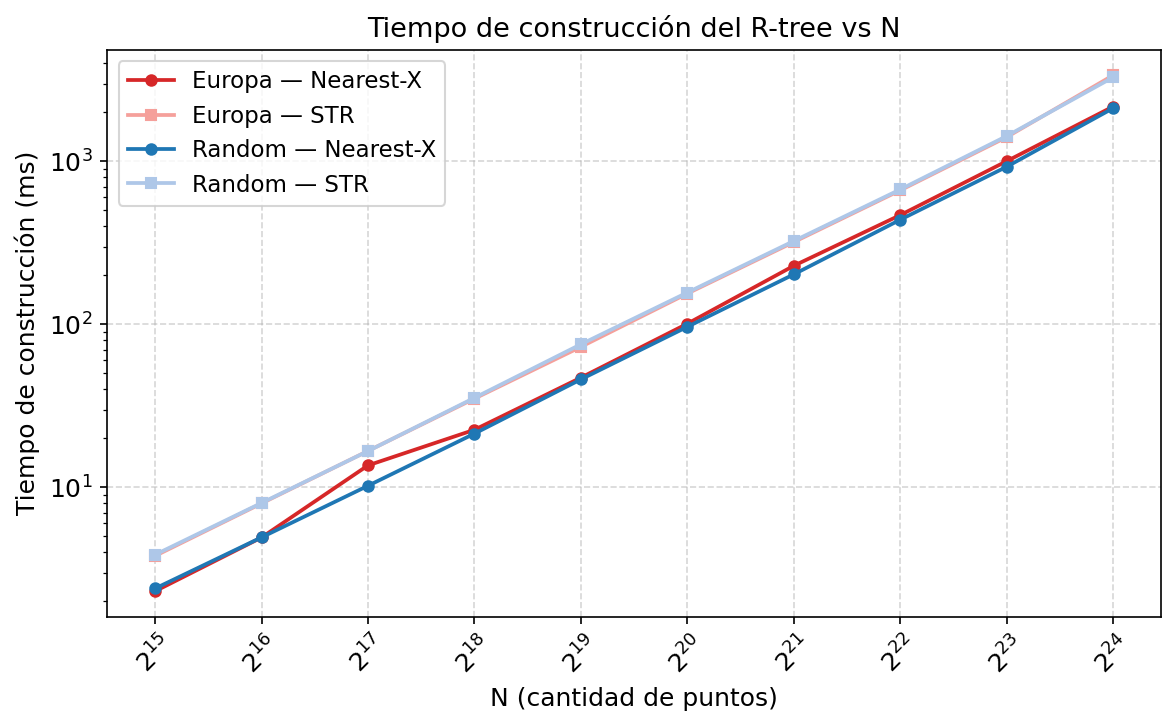

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for (ds, method), group in build.groupby(['dataset', 'method']):
    group = group.sort_values('N')
    key = (ds, method)
    ax.plot(group['N'], group['time_ms'],
            color=COLORS[key], marker=MARKERS[key],
            label=LABELS[key], linewidth=1.8, markersize=5)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('N (cantidad de puntos)')
ax.set_ylabel('Tiempo de construcción (ms)')
ax.set_title('Tiempo de construcción del R-tree vs N')

# Ticks en potencias de 2
ns = sorted(build['N'].unique())
ax.set_xticks(ns)
ax.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in ns], rotation=45)
ax.xaxis.set_minor_locator(ticker.NullLocator())

ax.legend()
ax.grid(True, which='major', linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig('plots/construccion_vs_N.pdf')
fig.savefig('plots/construccion_vs_N.png')
plt.show()

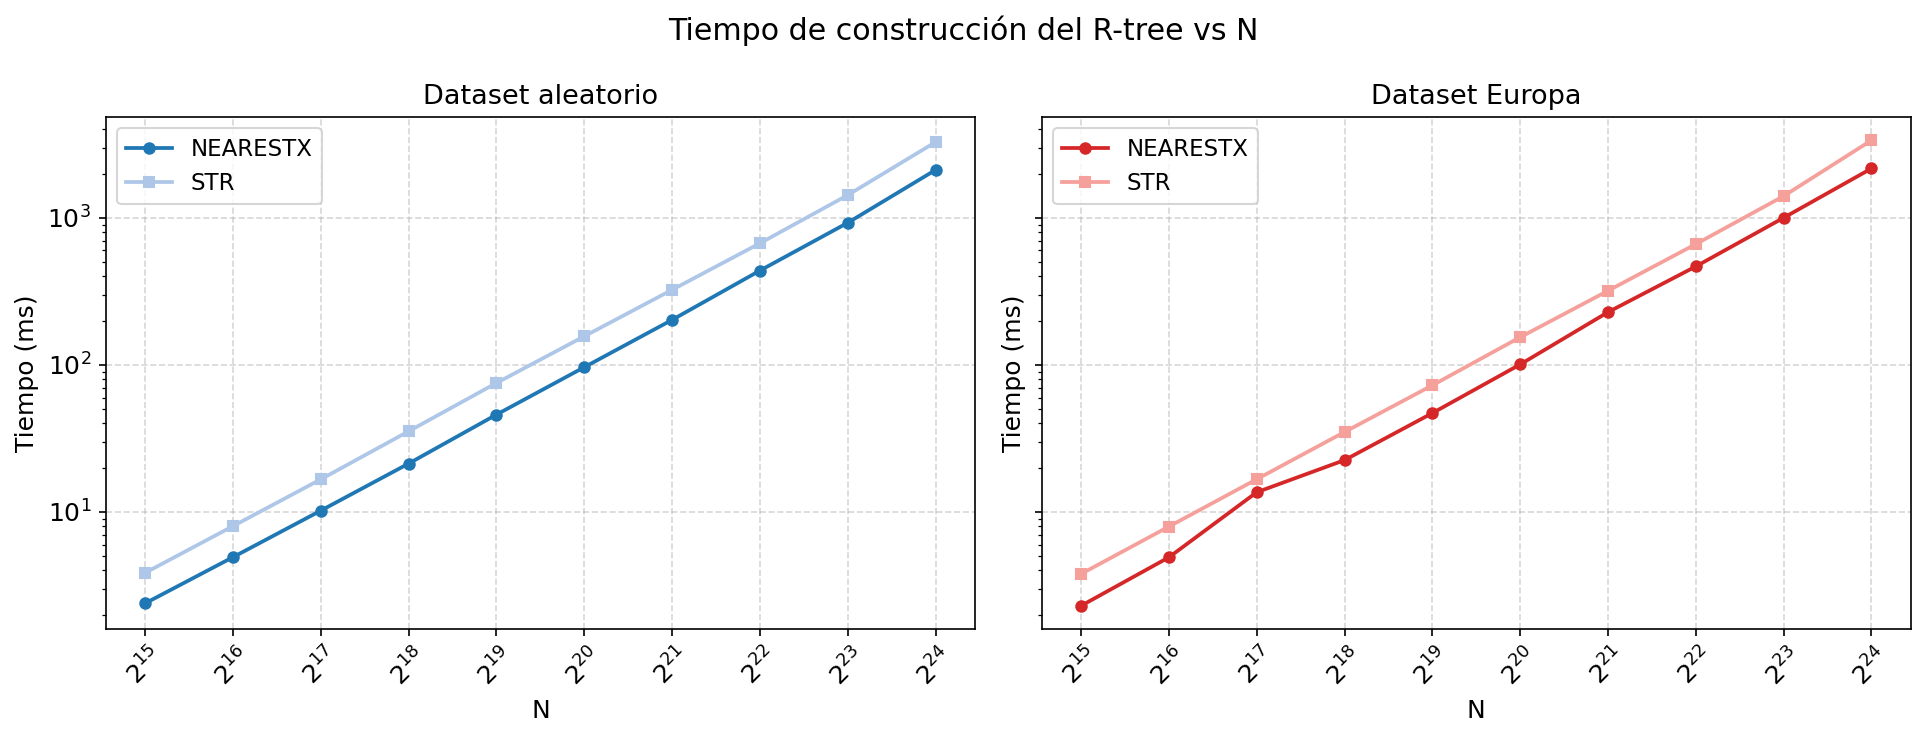

In [9]:
# Mismo gráfico separado por dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
dataset_titles = {'random': 'Dataset aleatorio', 'europa': 'Dataset Europa'}

for ax, ds in zip(axes, ['random', 'europa']):
    subset = build[build['dataset'] == ds]
    for method, group in subset.groupby('method'):
        group = group.sort_values('N')
        key = (ds, method)
        ax.plot(group['N'], group['time_ms'],
                color=COLORS[key], marker=MARKERS[key],
                label=method.upper(), linewidth=1.8, markersize=5)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('N')
    ax.set_ylabel('Tiempo (ms)')
    ax.set_title(dataset_titles[ds])
    ax.set_xticks(ns)
    ax.set_xticklabels([f'$2^{{{int(np.log2(n))}}}$' for n in ns], rotation=45)
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.legend()
    ax.grid(True, which='major', linestyle='--', alpha=0.5)

fig.suptitle('Tiempo de construcción del R-tree vs N')
fig.tight_layout()
fig.savefig('plots/construccion_vs_N_separado.pdf')
fig.savefig('plots/construccion_vs_N_separado.png')
plt.show()

## 5.2 — Consultas: I/O y puntos encontrados vs s

In [10]:
search = pd.read_csv('search_results.csv')
search.head()

,dataset,method,N,s,avg_io,avg_points,stddev_points
0,random,nearestx,16777216,0.0025,209.72,107.01,10.4542
1,random,str,16777216,0.0025,6.07,107.01,10.4542
2,europa,nearestx,16777216,0.0025,118.83,26.71,109.8270
3,europa,str,16777216,0.0025,4.64,26.71,109.8270
4,random,nearestx,16777216,0.0050,416.78,418.98,18.1829


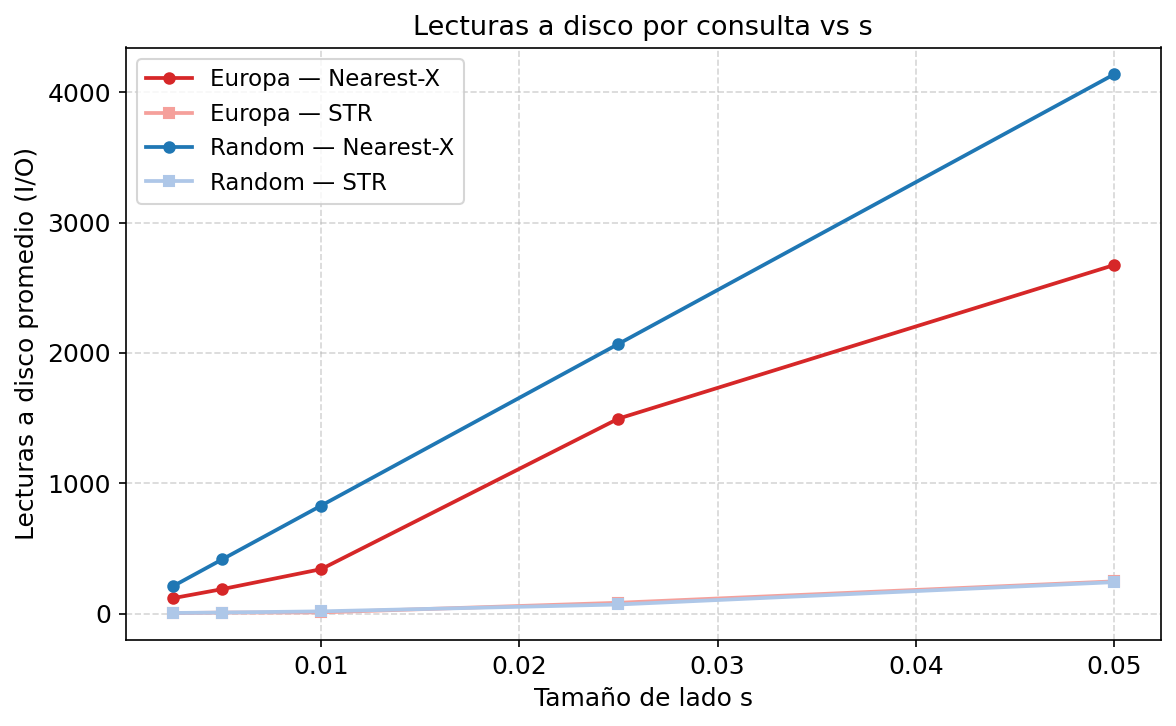

In [11]:
# Lecturas a disco (I/O) vs s
fig, ax = plt.subplots(figsize=(8, 5))

for (ds, method), group in search.groupby(['dataset', 'method']):
    group = group.sort_values('s')
    key = (ds, method)
    ax.plot(group['s'], group['avg_io'],
            color=COLORS[key], marker=MARKERS[key],
            label=LABELS[key], linewidth=1.8, markersize=5)

ax.set_xlabel('Tamaño de lado s')
ax.set_ylabel('Lecturas a disco promedio (I/O)')
ax.set_title('Lecturas a disco por consulta vs s')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig('plots/io_vs_s.pdf')
fig.savefig('plots/io_vs_s.png')
plt.show()

In [ ]:
# Puntos encontrados vs s (con barras de error = stddev)
# Separamos random y europa porque escalas muy distintas.
# Eje Y log para que stddev pequeño de random sea visible.
# Nota: avg_points/stddev idénticos entre nearestx y str → 1 curva por dataset.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

DATASET_COLORS = {'random': '#1f77b4', 'europa': '#d62728'}
DATASET_TITLES = {'random': 'Dataset aleatorio', 'europa': 'Dataset Europa'}

for ax, ds in zip(axes, ['random', 'europa']):
    group = (search[search['dataset'] == ds]
             .drop_duplicates(subset='s')
             .sort_values('s'))
    # Clip barra inferior para no ir bajo 0 (log scale exige > 0)
    yerr_lower = np.minimum(group['stddev_points'], group['avg_points'] * 0.9999)
    yerr_upper = group['stddev_points']
    ax.errorbar(group['s'], group['avg_points'],
                yerr=[yerr_lower, yerr_upper],
                color=DATASET_COLORS[ds], marker='o',
                linewidth=1.8, markersize=7,
                capsize=5, elinewidth=1.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Tamaño de lado s')
    ax.set_ylabel('Puntos encontrados promedio')
    ax.set_title(DATASET_TITLES[ds])
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

fig.suptitle('Puntos encontrados por consulta vs s (barras = desviación estándar)',
             fontsize=13)
fig.tight_layout()
fig.savefig('plots/puntos_vs_s.pdf')
fig.savefig('plots/puntos_vs_s.png')
plt.show()

In [ ]:
# Grilla 2x2: fila = dataset, columna = métrica
# I/O sí distingue método (nearestx vs str); puntos no (idénticos) → 1 curva por dataset.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
dataset_titles = {'random': 'Dataset aleatorio', 'europa': 'Dataset Europa'}

for row, ds in enumerate(['random', 'europa']):
    subset = search[search['dataset'] == ds]

    # Columna 0: I/O (separado por método)
    ax = axes[row][0]
    for method, group in subset.groupby('method'):
        group = group.sort_values('s')
        key = (ds, method)
        ax.plot(group['s'], group['avg_io'],
                color=COLORS[key], marker=MARKERS[key],
                label=method.upper(), linewidth=1.8, markersize=5)
    ax.set_title(f'{dataset_titles[ds]} — I/O promedio')
    ax.set_xlabel('s')
    ax.set_ylabel('I/O')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    # Columna 1: Puntos con stddev (una sola curva — método irrelevante)
    ax = axes[row][1]
    group = subset.drop_duplicates(subset='s').sort_values('s')
    ax.errorbar(group['s'], group['avg_points'],
                yerr=group['stddev_points'],
                color=DATASET_COLORS[ds], marker='o',
                linewidth=1.8, markersize=6,
                capsize=4, elinewidth=1)
    ax.set_title(f'{dataset_titles[ds]} — Puntos encontrados')
    ax.set_xlabel('s')
    ax.set_ylabel('Puntos')
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Resultados de consultas (N = 2²⁴)', fontsize=14)
fig.tight_layout()
fig.savefig('plots/consultas_grilla.pdf')
fig.savefig('plots/consultas_grilla.png')
plt.show()

## Tabla resumen de resultados

In [14]:
print('=== Construcción (N=2^24) ===')
print(build[build['N'] == 2**24].to_string(index=False))

=== Construcción (N=2^24) ===
dataset   method        N  time_ms
 random nearestx 16777216  2117.06
 random      str 16777216  3275.25
 europa nearestx 16777216  2167.19
 europa      str 16777216  3369.88


In [15]:
print('=== Consultas (todos los s) ===')
print(search.to_string(index=False))

=== Consultas (todos los s) ===
dataset   method        N      s  avg_io  avg_points  stddev_points
 random nearestx 16777216 0.0025  209.72      107.01        10.4542
 random      str 16777216 0.0025    6.07      107.01        10.4542
 europa nearestx 16777216 0.0025  118.83       26.71       109.8270
 europa      str 16777216 0.0025    4.64       26.71       109.8270
 random nearestx 16777216 0.0050  416.78      418.98        18.1829
 random      str 16777216 0.0050    9.27      418.98        18.1829
 europa nearestx 16777216 0.0050  188.78      558.23      2398.7100
 europa      str 16777216 0.0050    8.92      558.23      2398.7100
 random nearestx 16777216 0.0100  829.63     1679.71        49.2340
 random      str 16777216 0.0100   18.41     1679.71        49.2340
 europa nearestx 16777216 0.0100  342.24      769.92      2441.8800
 europa      str 16777216 0.0100   10.20      769.92      2441.8800
 random nearestx 16777216 0.0250 2069.60    10481.80       104.5730
 random      str

## 5.3 — Bonus: visualización de consulta en Europa no normalizada

Construcción de un R-tree (STR) sobre `datos/europa_bonus.bin` (coordenadas en lon/lat, rango aprox. lon∈[-11,35], lat∈[35,72]) y consulta por rectángulo alrededor de **Cádiz, España** (lon=-6.29, lat=36.53, medio lado=0.25°). N fijo en 2²⁴.

Prerequisito: `make bonus.out && ./bonus.out datos/europa_bonus.bin -6.29 36.53 0.25 trees/europa_bonus_str.bin bonus_points.csv`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

LON_C, LAT_C, H = -6.29, 36.53, 0.25

bg = np.fromfile('datos/europa_bonus.bin', dtype=np.float32).reshape(-1, 2)
bg = bg[::5000]

pts = pd.read_csv('bonus_points.csv')
print(f"Puntos en consulta: {len(pts)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.scatter(bg[:, 0], bg[:, 1], s=0.3, c='lightgray', alpha=0.5,
           label=f'Europa (submuestra 1/5000, n={len(bg)})')
ax.add_patch(Rectangle((LON_C - H, LAT_C - H), 2*H, 2*H,
                       fill=False, ec='red', lw=1.5, label='Rectángulo consulta'))
ax.scatter(pts.x, pts.y, s=3, c='C0', label=f'Puntos retornados ({len(pts)})')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Bonus 5.3 — Contexto en Europa')
ax.set_aspect('equal')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(True, ls=':', alpha=0.5)

ax = axes[1]
margin = H * 0.2
ax.scatter(pts.x, pts.y, s=8, c='C0', alpha=0.7)
ax.add_patch(Rectangle((LON_C - H, LAT_C - H), 2*H, 2*H,
                       fill=False, ec='red', lw=1.5))
ax.set_xlim(LON_C - H - margin, LON_C + H + margin)
ax.set_ylim(LAT_C - H - margin, LAT_C + H + margin)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Zoom — Cádiz, España ({len(pts)} edificios)')
ax.set_aspect('equal')
ax.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/bonus_cadiz.png', dpi=150, bbox_inches='tight')
plt.savefig('plots/bonus_cadiz.pdf', bbox_inches='tight')
plt.show()
